In [1]:
%display latex
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (7, 3.5)

In [2]:
def controlled_root_formulation(N, *, rate_only=False):
    n_roots = N + 1 if rate_only else N

    root_vars = [f"z{n}" for n in range(n_roots)]
    K_vars = [f"K{n}" for n in range(1, N + 1)]
    var_array = ["z"] + root_vars + K_vars
    # R = Q[z, z0, ..., zM, K1, ..., KN]
    R = PolynomialRing(QQ, var_array)
    z = R.0
    roots = [R.gen(1 + n) for n in range(n_roots)]
    Ks = [R.gen(1 + n_roots + n) for n in range(N)]

    # S = Q[z0, ..., zM, K1, ..., KN]
    S = PolynomialRing(QQ, roots + Ks)

    # T = Q[K1, ..., KN]
    T = PolynomialRing(QQ, Ks)

    # U = T[z0, ..., zM] = Q[K1, ..., KN][z0, ..., zM]
    U = PolynomialRing(T, roots)

    # S -> U natural isomorphism
    S_to_U = S.hom(list(U.gens()) + [U(Tgen) for Tgen in T.gens()])

    # Symmetric polynomials on Q[K1, ..., KN]
    Sym = SymmetricFunctions(T)
    # basis of elementary symmetric polynomials on Q[K1, ..., KN]
    Elementary = Sym.elementary()

    if rate_only:
        D = z * (z - 1)^N + (z + 1) / 2 * sum([(z - 1)^(N - 1 - j) * z^j * Ks[j] for j in range(N)])
    else:
        D = (z - 1)^N + sum([(z - 1)^(N - 1 - j) * z^j * Ks[j] for j in range(N)])
    D_roots = prod([z - zj for zj in roots])
    D_lead = z * (z - 1)^N if rate_only else (z - 1)^N
    H = (D - D_lead) / D_roots
    BLT = sum([((z - w) * H * H.subs(z=z^-1) * z^-1).subs(z=w) for w in roots]) / 2

    assert T[z](D).coefficients()[-1] == 1
    elementary_eqs = [(-1)^(n_roots - j) * coeff for j, coeff in enumerate(T[z](D).coefficients()[:-1])]

    def to_symm(poly):
        return Elementary.from_polynomial(S_to_U(S(poly)))

    def elem_subst(idx):
        assert idx >= 1
        if idx > len(elementary_eqs):
            return 0
        return elementary_eqs[n_roots - idx]

    def symm_subst(symm):
        return sum([symm.coefficient(a) * product([elem_subst(aa) for aa in a]) for a in symm.support()])

    def root_symm_subst(poly):
        return symm_subst(to_symm(poly))

    if n_roots == 1:
        # In this case we only have one root, so instead of using symmetric polynomials in the
        # roots, we directly replace the root by its value
        BLT_K = BLT.subs({roots[0]: elementary_eqs[0]})
    else:
        BLT_K = root_symm_subst(BLT.numerator()) / root_symm_subst(BLT.denominator())
    results = {'BLT': BLT_K, 'elementary_eqs': elementary_eqs}
    
    return results

In [3]:
controlled_root_formulation(1)['BLT']

K1/(-2*K1 + 4)

In [4]:
controlled_root_formulation(2)['BLT']

(2*K1^2 + K1*K2 + 2*K2)/(-4*K1^2 - 2*K1*K2 + 8*K1)

In [5]:
controlled_root_formulation(3)['BLT']

(4*K1^2*K2 + 2*K1*K2^2 + 4*K1^2*K3 + 3*K1*K2*K3 + K1*K3^2 + 4*K2^2 - 4*K1*K3 + 4*K2*K3 + K3^2)/(-8*K1^2*K2 - 4*K1*K2^2 - 8*K1^2*K3 - 6*K1*K2*K3 - 2*K1*K3^2 + 16*K1*K2 + 24*K1*K3 + 4*K2*K3 + 2*K3^2 - 16*K3)

In [6]:
controlled_root_formulation(4)['BLT']

(8*K1^2*K2*K3 + 4*K1*K2^2*K3 + 8*K1^2*K3^2 + 6*K1*K2*K3^2 + 2*K1*K3^3 - 8*K1^3*K4 + 4*K1^2*K2*K4 + 4*K1*K2^2*K4 + 14*K1^2*K3*K4 + 11*K1*K2*K3*K4 + 5*K1*K3^2*K4 + 7*K1^2*K4^2 + 5*K1*K2*K4^2 + 4*K1*K3*K4^2 + K1*K4^3 + 8*K2^2*K3 - 8*K1*K3^2 + 8*K2*K3^2 + 2*K3^3 - 8*K1*K2*K4 + 8*K2^2*K4 - 20*K1*K3*K4 + 14*K2*K3*K4 + 5*K3^2*K4 - 10*K1*K4^2 + 6*K2*K4^2 + 4*K3*K4^2 + K4^3 - 8*K3*K4 - 8*K4^2)/(-16*K1^2*K2*K3 - 8*K1*K2^2*K3 - 16*K1^2*K3^2 - 12*K1*K2*K3^2 - 4*K1*K3^3 + 16*K1^3*K4 - 8*K1^2*K2*K4 - 8*K1*K2^2*K4 - 28*K1^2*K3*K4 - 22*K1*K2*K3*K4 - 10*K1*K3^2*K4 - 14*K1^2*K4^2 - 10*K1*K2*K4^2 - 8*K1*K3*K4^2 - 2*K1*K4^3 + 32*K1*K2*K3 + 48*K1*K3^2 + 8*K2*K3^2 + 4*K3^3 - 32*K1^2*K4 + 32*K1*K2*K4 + 96*K1*K3*K4 + 16*K2*K3*K4 + 10*K3^2*K4 + 48*K1*K4^2 + 8*K2*K4^2 + 8*K3*K4^2 + 2*K4^3 - 32*K3^2 - 64*K3*K4 - 32*K4^2)

In [7]:
controlled_root_formulation(1, rate_only=True)['BLT']

-1/2*K1/(K1 - 2)

In [8]:
controlled_root_formulation(2, rate_only=True)['BLT']

(1/2*K1^2 + 1/4*K1*K2 + 1/2*K2)/(-K1^2 - 1/2*K1*K2 + 2*K1 - K2)

In [9]:
controlled_root_formulation(3, rate_only=True)['BLT']

(1/2*K1^2*K2 + 1/4*K1*K2^2 + 1/2*K1^2*K3 + 3/8*K1*K2*K3 + 1/8*K1*K3^2 + 1/2*K2^2 - 1/2*K1*K3 + 1/4*K2*K3)/(-K1^2*K2 - 1/2*K1*K2^2 - K1^2*K3 - 3/4*K1*K2*K3 - 1/4*K1*K3^2 + 2*K1*K2 - K2^2 + 3*K1*K3 - 1/2*K2*K3 - 2*K3)

In [10]:
controlled_root_formulation(4, rate_only=True)['BLT']

(1/2*K1^2*K2*K3 + 1/4*K1*K2^2*K3 + 1/2*K1^2*K3^2 + 3/8*K1*K2*K3^2 + 1/8*K1*K3^3 - 1/2*K1^3*K4 + 1/4*K1^2*K2*K4 + 1/4*K1*K2^2*K4 + 7/8*K1^2*K3*K4 + 11/16*K1*K2*K3*K4 + 5/16*K1*K3^2*K4 + 7/16*K1^2*K4^2 + 5/16*K1*K2*K4^2 + 1/4*K1*K3*K4^2 + 1/16*K1*K4^3 + 1/2*K2^2*K3 - 1/2*K1*K3^2 + 1/4*K2*K3^2 - 1/2*K1*K2*K4 + 1/2*K2^2*K4 - 3/4*K1*K3*K4 + 3/8*K2*K3*K4 + 1/8*K2*K4^2 - 1/2*K3*K4 - 1/4*K4^2)/(-K1^2*K2*K3 - 1/2*K1*K2^2*K3 - K1^2*K3^2 - 3/4*K1*K2*K3^2 - 1/4*K1*K3^3 + K1^3*K4 - 1/2*K1^2*K2*K4 - 1/2*K1*K2^2*K4 - 7/4*K1^2*K3*K4 - 11/8*K1*K2*K3*K4 - 5/8*K1*K3^2*K4 - 7/8*K1^2*K4^2 - 5/8*K1*K2*K4^2 - 1/2*K1*K3*K4^2 - 1/8*K1*K4^3 + 2*K1*K2*K3 - K2^2*K3 + 3*K1*K3^2 - 1/2*K2*K3^2 - 2*K1^2*K4 + 3*K1*K2*K4 - K2^2*K4 + 11/2*K1*K3*K4 - 3/4*K2*K3*K4 + 2*K1*K4^2 - 1/4*K2*K4^2 - 2*K3^2 - 2*K3*K4 - 1/2*K4^2)

In [11]:
results = controlled_root_formulation(2, rate_only=True)

In [12]:
results['elementary_eqs']

[1/2*K1, 1/2*K2 + 1, -1/2*K1 - 1/2*K2 + 2]

In [13]:
R.<w, v> = QQ[]

In [14]:
wv_poly = QQ[w][v](results['elementary_eqs'][2].subs(K1=2*w^2*v, K2=2*(w^2+2*w*v-1)) - (2*w + v))
wv_poly

(-w^2 - 2*w - 1)*v - w^2 - 2*w + 3

In [15]:
v_subs = -wv_poly.coefficients()[0]/wv_poly.coefficients()[1]
v_subs

(-w^2 - 2*w + 3)/(w^2 + 2*w + 1)

In [16]:
K1_subs = 2 * QQ[w](w)^2 * v_subs
K2_subs = 2 * (QQ[w](w)^2 + 2 * QQ[w](w) * v_subs - 1)

In [17]:
K1_subs

(-2*w^4 - 4*w^3 + 6*w^2)/(w^2 + 2*w + 1)

In [18]:
K2_subs

(2*w^4 - 8*w^2 + 8*w - 2)/(w^2 + 2*w + 1)

In [19]:
BLT_w = results['BLT'].subs(K1=K1_subs, K2=K2_subs)
BLT_w

(-1/2*w^6 - 3*w^5 - 5/2*w^4 + 6*w^3 - 1/2*w^2 + w - 1/2)/(w^6 + 6*w^5 + 7*w^4 - 4*w^3 + 7*w^2 - 2*w + 1)

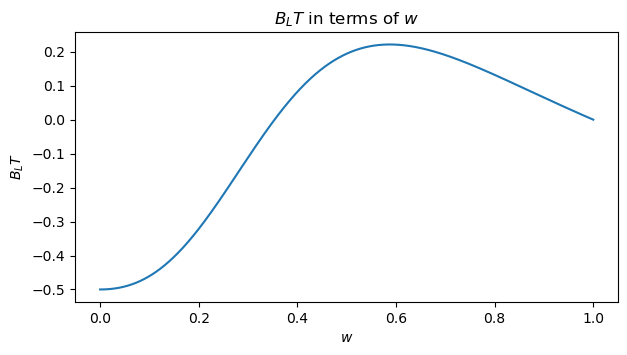

In [20]:
ws_array = np.linspace(0, 1, 1000)
plt.plot(ws_array, np.array([BLT_w.subs(w=w) for w in ws_array]))
plt.title('$B_L T$ in terms of $w$')
plt.xlabel('$w$')
plt.ylabel('$B_L T$');

In [21]:
w_max = [r[0] for r in BLT_w.derivative().numerator().roots(CC) if r[0].is_real() and 0 < r[0] < 1][0]
w_max

0.587401051968199

In [22]:
BLT_w.subs(w_max)

0.221372894099326

In [23]:
def solve_w(BLT):
    return max([r[0] for r in (BLT_w.numerator() - BLT * BLT_w.denominator()).roots(CC) if r[0].is_real() and 0 < r[0] < 1])

In [24]:
BLTs = np.logspace(-3, np.log10(0.2), 1000)
ws = np.array([np.float64(solve_w(BLT)) for BLT in BLTs])
K1s = np.array([K1_subs.subs(w=w) for w in ws])
K2s = np.array([K2_subs.subs(w=w) for w in ws])
BLT_check = np.array([results['BLT'].subs(K1=K1, K2=K2) for K1, K2 in zip(K1s, K2s)])

In [25]:
assert np.all(np.abs(BLT_check - BLTs) < 1e-10)

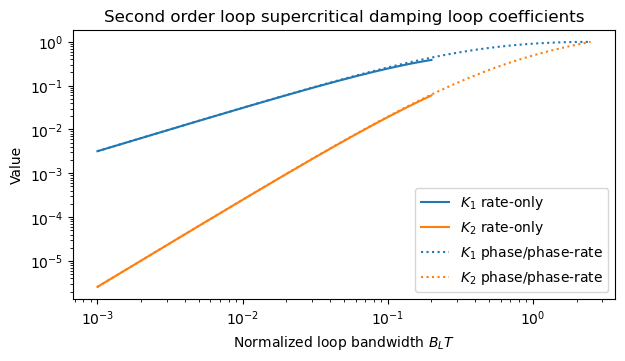

In [26]:
def phase_phase_rate_loop_coefficients(BLT):
    Delta = np.cbrt(36 * BLT**2 + np.sqrt(3) * np.sqrt(432 * BLT**4 + 848 * BLT**3 + 624 * BLT**2+ 204 * BLT + 25) +
                    36 * BLT + 9)
    z = ((12 * BLT + 6) / (3 * np.cbrt(6) * (2 * BLT + 1) * Delta) +
        (np.cbrt(2) * Delta) / (np.cbrt(9) * (2 * BLT + 1)) - 1)
    K1 = 1 - z**2
    K2 = (1 - z)**2
    return K1, K2

BLTs_phase_phase_rate = np.logspace(-3, np.log10(2.5), 1000)
plt.loglog(BLTs, K1s, label='$K_1$')
plt.loglog(BLTs, K2s, label='$K_2$')
plt.gca().set_prop_cycle(None)
plt.loglog(BLTs_phase_phase_rate, np.array(phase_phase_rate_loop_coefficients(BLTs_phase_phase_rate)).T, ':')
plt.title('Second order loop supercritical damping loop coefficients')
plt.xlabel('Normalized loop bandwidth $B_LT$')
plt.ylabel('Value')
plt.legend(['$K_1$ rate-only', '$K_2$ rate-only', '$K_1$ phase/phase-rate', '$K_2$ phase/phase-rate']);

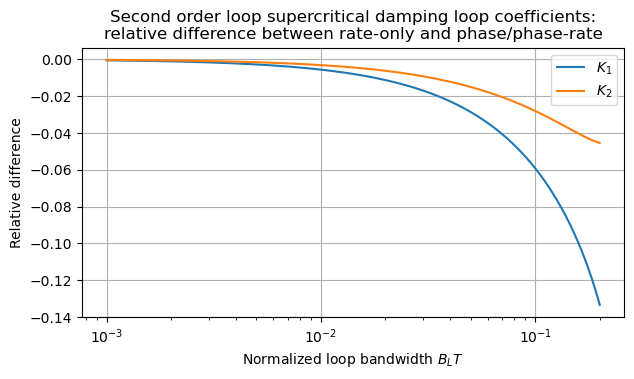

In [27]:
plt.semilogx(BLTs, (K1s - np.array(phase_phase_rate_loop_coefficients(BLTs))[0]) / K1s, label='$K_1$')
plt.semilogx(BLTs, (K2s - np.array(phase_phase_rate_loop_coefficients(BLTs))[1]) / K2s, label='$K_2$')
plt.title('Second order loop supercritical damping loop coefficients:\nrelative difference between rate-only and phase/phase-rate')
plt.xlabel('Normalized loop bandwidth $B_LT$')
plt.ylabel('Relative difference')
plt.grid()
plt.legend();

In [28]:
BLT_w

(-1/2*w^6 - 3*w^5 - 5/2*w^4 + 6*w^3 - 1/2*w^2 + w - 1/2)/(w^6 + 6*w^5 + 7*w^4 - 4*w^3 + 7*w^2 - 2*w + 1)

In [29]:
BLT_w_pade = BLT_w.subs(w=x+1).taylor(x, 0, 100).power_series(QQ).pade(2, 2).subs(x=x-1)
BLT_w_pade.numerator() / BLT_w_pade.denominator()

-25/16*(47*x^2 - 60*x + 13)/(131*x^2 - 102*x + 56)

In [30]:
BLT = var('BLT')
assume(BLT > 0)
(BLT_w_pade - BLT).solve(x)[1]

x == (816*BLT + sqrt(-1212160*BLT^2 - 510000*BLT + 180625) + 750)/(2096*BLT + 1175)

In [31]:
def rate_only_approx_w(BLT):
    return (816 * BLT + np.sqrt(-1212160 * BLT**2 - 510000 * BLT + 180625) + 750) / (2096 * BLT + 1175)

def rate_only_approx_loop_coefficients(BLT):
    w = rate_only_approx_w(BLT)
    K1 = (-2 * w**4 - 4 * w**3 + 6 * w**2) / (w**2 + 2 * w + 1)
    K2 = (2 * w**4 - 8 * w**2 + 8 * w - 2) / (w**2 + 2 * w + 1)
    return K1, K2

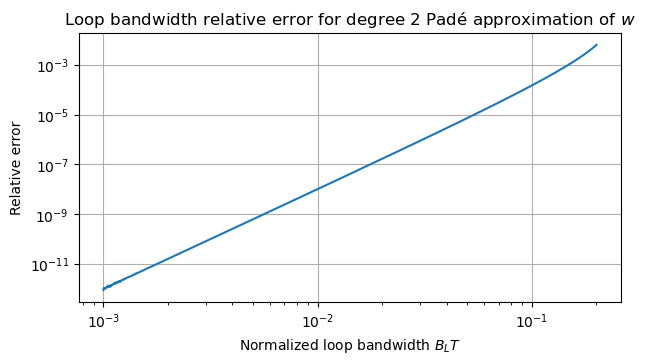

In [32]:
BLTs_approx = np.array([BLT_w.subs(w=w) for w in rate_only_approx_w(BLTs)])
plt.loglog(BLTs, np.abs(BLTs_approx - BLTs) / BLTs)
plt.title('Loop bandwidth relative error for degree 2 Padé approximation of $w$')
plt.xlabel('Normalized loop bandwidth $B_LT$')
plt.ylabel('Relative error')
plt.grid();

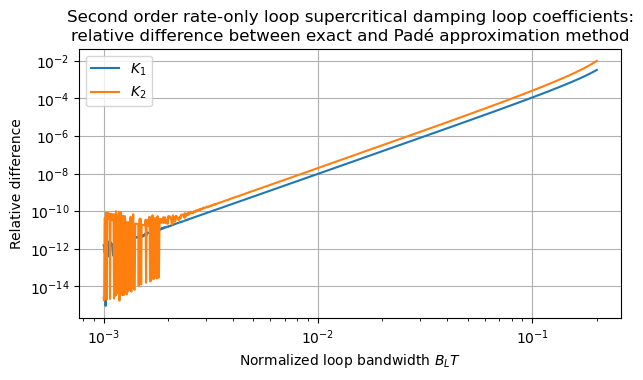

In [33]:
plt.loglog(BLTs, np.abs(K1s - np.array(rate_only_approx_loop_coefficients(BLTs))[0]) / K1s, label='$K_1$')
plt.loglog(BLTs, np.abs(K2s - np.array(rate_only_approx_loop_coefficients(BLTs))[1]) / K2s, label='$K_2$')
plt.title('Second order rate-only loop supercritical damping loop coefficients:\nrelative difference between exact and Padé approximation method')
plt.xlabel('Normalized loop bandwidth $B_LT$')
plt.ylabel('Relative difference')
plt.grid()
plt.legend();

In [34]:
BLTs_table = np.array([0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.15, 0.2])
K1s_table = np.array([0.01575, 0.03109, 0.04602, 0.06054, 0.07466, 0.0884, 0.1018, 0.1148, 0.1274, 0.1397, 0.1634, 0.1858,
                      0.2070, 0.2271, 0.2461, 0.3268, 0.3864])
K2s_table = np.array([6.275e-5, 2.475e-4, 5.486e-4, 9.607e-4, 0.001479, 0.002097, 0.002812, 0.003619, 0.004513,
                      0.005491, 0.007683, 0.01016, 0.01291, 0.01590, 0.01911, 0.03784, 0.05992])
ws_table = np.array([np.float64(solve_w(BLT)) for BLT in BLTs_table])
K1s_table_calc = np.array([K1_subs.subs(w=w) for w in ws_table])
K2s_table_calc = np.array([K2_subs.subs(w=w) for w in ws_table])

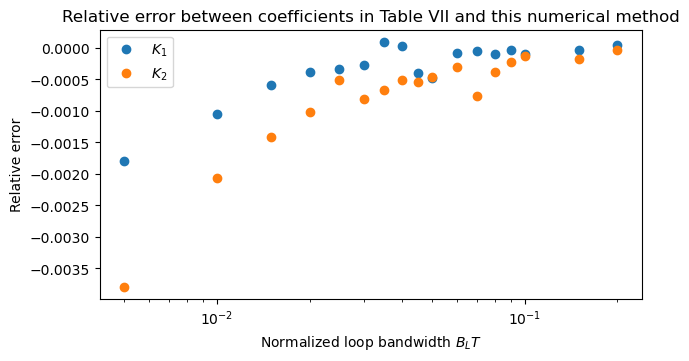

In [35]:
plt.semilogx(BLTs_table, (K1s_table - K1s_table_calc) / K1s_table_calc, 'o', label='$K_1$')
plt.semilogx(BLTs_table, (K2s_table - K2s_table_calc) / K2s_table_calc, 'o', label='$K_2$')
plt.title('Relative error between coefficients in Table VII and this numerical method')
plt.xlabel('Normalized loop bandwidth $B_LT$')
plt.ylabel('Relative error')
plt.legend();